In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aabdollahii/wikidata-persian/knowledge_graph_triples.csv


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the dataset (replace with your Kaggle path if different)
file_path = "/kaggle/input/datasets/aabdollahii/wikidata-persian/knowledge_graph_triples.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. Basic Statistics
total_triples = len(df)
unique_subjects = df["Subject"].nunique()
unique_predicates = df["Predicate"].nunique()
unique_objects = df["Object"].nunique()

all_entities = pd.concat([df["Subject"], df["Object"]]).astype(str)
unique_entities = all_entities.nunique()

print("=== Basic Dataset Statistics ===")
print(f"Total Triples (Facts): {total_triples}")
print(f"Unique Subjects: {unique_subjects}")
print(f"Unique Predicates (Relations): {unique_predicates}")
print(f"Unique Objects: {unique_objects}")
print(f"Total Unique Entities: {unique_entities}\n")

=== Basic Dataset Statistics ===
Total Triples (Facts): 2275010
Unique Subjects: 226414
Unique Predicates (Relations): 15571
Unique Objects: 1015095
Total Unique Entities: 1090676



In [3]:
# 3. Density and Graph-related metrics
# Density = Edges / (Vertices * (Vertices - 1))
if unique_entities > 1:
    graph_density = total_triples / (unique_entities * (unique_entities - 1))
    print(f"Graph Density: {graph_density:.6f}")
else:
    print("Graph Density: N/A")

Graph Density: 0.000002


In [4]:
# 4. Top Predicates (Relations Distribution)
top_predicates = df["Predicate"].value_counts().head(10)
print("\n=== Top 10 Most Frequent Predicates ===")
print(top_predicates)

# 5. Top Entities (Subjects & Objects combined)
top_entities = all_entities.value_counts().head(10)
print("\n=== Top 10 Most Frequent Entities ===")
print(top_entities)

# 6. Check for Missing Values
missing_values = df.isnull().sum()
print("\n=== Missing Values Per Column ===")
print(missing_values)


=== Top 10 Most Frequent Predicates ===
Predicate
نام             97745
استان           86438
شهرستان         83211
تصویر           62349
بخش             60490
نام رسمی        55756
جمعیت           55528
دهستان          54759
کد آماری        45048
اندازه تصویر    30484
Name: count, dtype: int64

=== Top 10 Most Frequent Entities ===
آری            26879
250            23411
بخش مرکزی      16614
مرکزی          12913
yes            12789
#FFFFC0        11698
مه ۱۴, ۲۰۰۸    10715
ایران          10089
انگلیسی         8439
دوره قاجار      7904
Name: count, dtype: int64

=== Missing Values Per Column ===
Subject        0
Predicate      4
Object       119
dtype: int64


/tmp/ipykernel_59/2198860616.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_59/2198860616.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


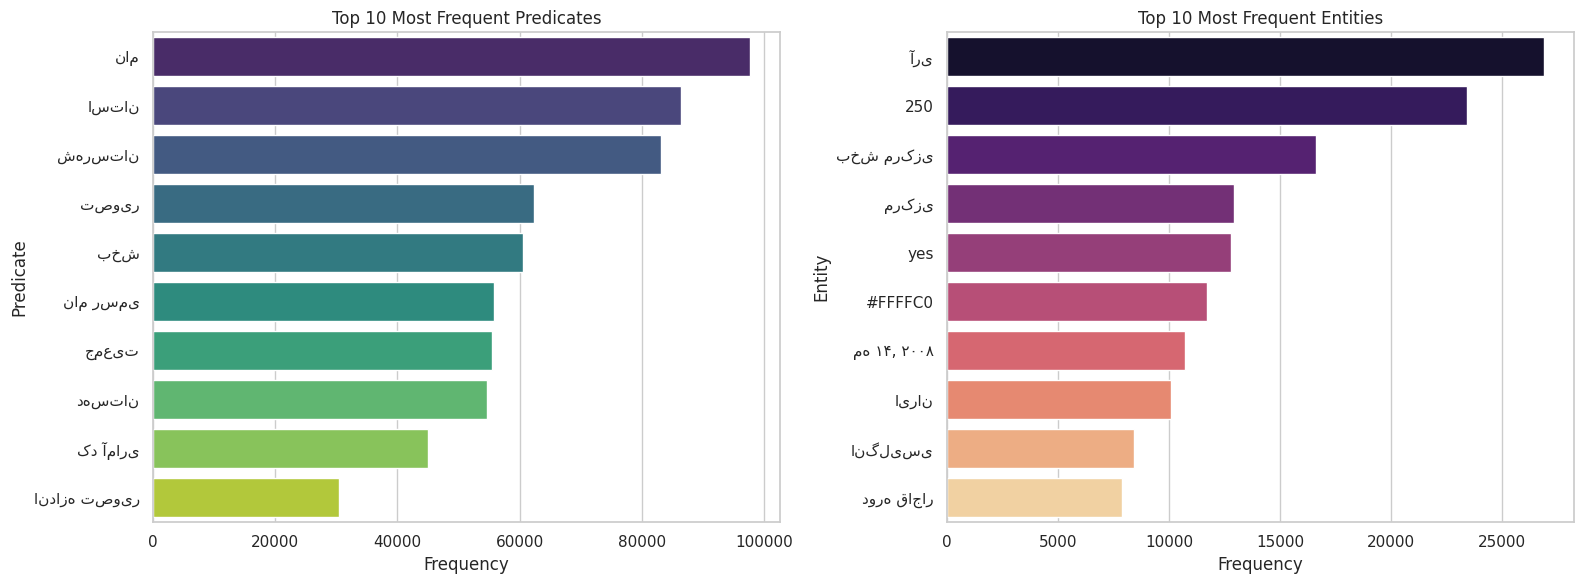

In [5]:
# 7. Visualization
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Top Predicates
sns.barplot(
    x=top_predicates.values,
    y=top_predicates.index,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top 10 Most Frequent Predicates")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Predicate")

# Plot Top Entities
sns.barplot(
    x=top_entities.values,
    y=top_entities.index,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Top 10 Most Frequent Entities")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Entity")

plt.tight_layout()
plt.show()